# **Guió desafiament Nº1** 

Basado en la información del dataset ***Bank Marketing*** una vez limpiado = (https://github.com/ITACADEMYprojectes/ProjecteData/blob/Equip_23/Equip_23/Data/Bank_Marketing_Cleaned.csv)"

**Pregunta para Analistes de Màrqueting i Comunicació:**

Quina relació hi ha entre el nombre de contactes realitzats durant aquesta campanya i la taxa d'èxit, i com podem optimitzar la freqüència de contacte per maximitzar els resultats de les nostres campanyes de màrqueting? 

### Cargamos el dataset


In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Portátil\ProjecteData\Equip_23\Data\Bank_Marketing_Cleaned.csv")
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,1,59,admin.,married,secondary,no,2343,yes,no,unknown,5,5,1042,1,-1,0,unknown,yes
1,2,56,admin.,married,secondary,no,45,no,no,unknown,5,5,1467,1,-1,0,unknown,yes
2,3,41,technician,married,secondary,no,1270,yes,no,unknown,5,5,1389,1,-1,0,unknown,yes
3,4,55,services,married,secondary,no,2476,yes,no,unknown,5,5,579,1,-1,0,unknown,yes
4,5,54,admin.,married,tertiary,no,184,no,no,unknown,5,5,673,2,-1,0,unknown,yes


Consideramos que en el dataset hay dos variables importantes para responder a la pregunta planteada a los analistas de marketing y comunicación: “campaign” y “deposit”.Aprofundimos más en el estudio de estas variables para conocer mejor su composición y la relación existente entre ambas.

### Distribución del número de contactos realizados por cliente en la campaña

In [5]:
df['campaign'].value_counts().sort_index()

campaign
1     4592
2     2885
3     1256
4      741
5      356
6      245
7      128
8      121
9       69
10      51
11      39
12      27
13      30
14      14
15      12
16       8
17      13
18       8
19       5
20       4
21       7
22       4
23       3
24       5
25       3
26       3
27       1
28       1
29       2
30       1
31       1
32       2
33       1
41       1
43       2
63       1
Name: count, dtype: int64

### Valores absolutos de clientes que contratan el depósito

In [6]:
success_number = df.groupby('campaign')['deposit'].apply(lambda x: (x=='yes').sum())
print(success_number)

campaign
1     2561
2     1401
3      618
4      317
5      139
6       92
7       47
8       32
9       21
10      14
11      16
12       4
13       6
14       4
15       4
16       2
17       6
18       0
19       0
20       1
21       1
22       0
23       0
24       1
25       0
26       0
27       0
28       0
29       1
30       0
31       0
32       1
33       0
41       0
43       0
63       0
Name: deposit, dtype: int64


### Porcentaje de exito según el número de llamadas

Alto porcentaje de aceptación en las 3 primeras llamadas; a partir de ahí la tasa cae de forma progresiva y las conversiones se vuelven muy bajas.

In [7]:
success_rate = df.groupby('campaign')['deposit'].apply(lambda x: (x=='yes').mean() * 100)
print(success_rate)

campaign
1     55.770906
2     48.561525
3     49.203822
4     42.780027
5     39.044944
6     37.551020
7     36.718750
8     26.446281
9     30.434783
10    27.450980
11    41.025641
12    14.814815
13    20.000000
14    28.571429
15    33.333333
16    25.000000
17    46.153846
18     0.000000
19     0.000000
20    25.000000
21    14.285714
22     0.000000
23     0.000000
24    20.000000
25     0.000000
26     0.000000
27     0.000000
28     0.000000
29    50.000000
30     0.000000
31     0.000000
32    50.000000
33     0.000000
41     0.000000
43     0.000000
63     0.000000
Name: deposit, dtype: float64


### Porcentaje de éxito o no según el número de llamadas

In [8]:
df.groupby('campaign')['deposit'].value_counts(normalize=True).mul(100).round(2)

campaign  deposit
1         yes         55.77
          no          44.23
2         no          51.44
          yes         48.56
3         no          50.80
          yes         49.20
4         no          57.22
          yes         42.78
5         no          60.96
          yes         39.04
6         no          62.45
          yes         37.55
7         no          63.28
          yes         36.72
8         no          73.55
          yes         26.45
9         no          69.57
          yes         30.43
10        no          72.55
          yes         27.45
11        no          58.97
          yes         41.03
12        no          85.19
          yes         14.81
13        no          80.00
          yes         20.00
14        no          71.43
          yes         28.57
15        no          66.67
          yes         33.33
16        no          75.00
          yes         25.00
17        no          53.85
          yes         46.15
18        no         100.00
19

### Número de clientes que adquirieron o no el depósito

In [9]:
df['deposit'].value_counts().sort_index()

deposit
no     5353
yes    5289
Name: count, dtype: int64

### Número de clientes según el número de llamadas realizadas (1–10)

Vemos que, a partir de las 10 llamadas a un mismo cliente, el éxito cae por debajo del 30%; por tanto, acotamos la muestra.

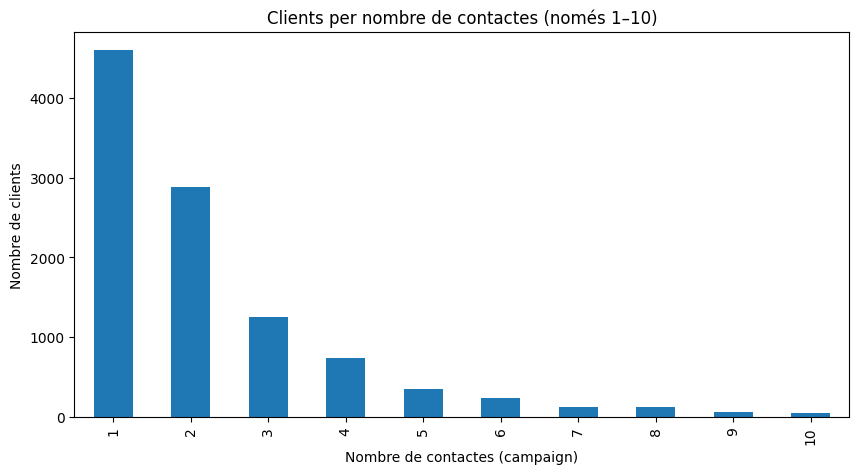

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

df['campaign'].value_counts().sort_index().loc[1:10].plot(
    kind='bar',
    figsize=(10,5)
)

plt.xlabel('Nombre de contactes (campaign)')
plt.ylabel('Nombre de clients')
plt.title('Clients per nombre de contactes (només 1–10)')
plt.show()

### Tasa de éxito del depósito según el número de contactos de campaña

La tasa de éxito del depósito en función del número de contactos realizados. Permite identificar a partir de cuántas llamadas la probabilidad de conversión disminuye.

<Axes: xlabel='campaign'>

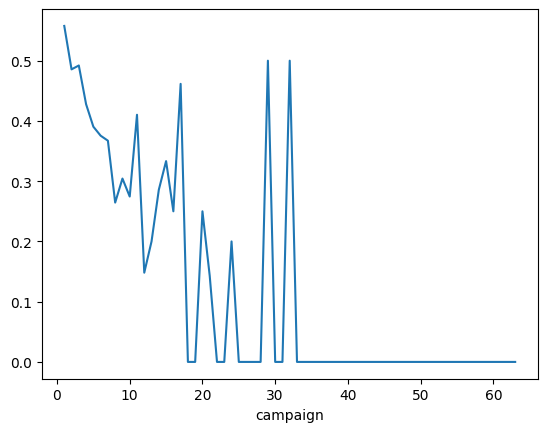

In [11]:
success_rate = df.groupby('campaign')['deposit'].apply(lambda x: (x=='yes').mean())
success_rate.plot(kind='line')

Explicación de la subida entre 25 y 35 campaign: 
- A partir de 20–25 contactos, el número de observaciones es mínimo.
Cuando hay pocos datos, cualquier pequeño cambio provoca grandes oscilaciones en la tasa de éxito.

In [12]:
# Número total de clientes por número de llamadas
total_clients = df['campaign'].value_counts().sort_index()

# Número de éxitos (clientes que dijeron "yes") por número de llamadas
success_number = df.groupby('campaign')['deposit'].apply(lambda x: (x=='yes').sum())

# Mostrar ambos entre 25 y 35 llamadas
result = pd.DataFrame({
    'clientes_totales': total_clients,
    'clientes_yes': success_number
}).loc[25:35]

print(result)


          clientes_totales  clientes_yes
campaign                                
25                       3             0
26                       3             0
27                       1             0
28                       1             0
29                       2             1
30                       1             0
31                       1             0
32                       2             1
33                       1             0


### Correlación entre variables

In [27]:
# crear columna numérica (yes=1, no=0) para trabajar con correlaciones
df['deposit_numeric'] = df['deposit'].map({'yes': 1, 'no': 0})



In [26]:
correlation = df['campaign'].corr(df['deposit_numeric'])
print("Correlation:", correlation)

Correlation: -0.13099512785187523


La correlación negativa (–0.13) indica que, en general, aumentar el número de llamadas reduce ligeramente la probabilidad de aceptació.

### Conlusiones:
El análisis muestra que:
- La tasa de éxito es máxima con 1 contacto (55,77%)
- Con 2 y 3 contactos, el éxito se mantiene alto (48–49%)
- A partir de 4 contactos, la tasa de éxito disminuye progresivamente
- Entre 8 y 10 contactos, el éxito cae por debajo del 30%
- A partir de 12 contactos, prácticamente no hay conversiones

Esto, junto con una correlación negativa (–0,13), indica que realizar más contactos no mejora los resultados, sino que los empeora.

### Recomendación para optimizar la frecuencia de contacto:
- El punto óptimo se sitúa entre 1 y 3 contactos.
- A partir del cuarto contacto, la probabilidad de éxito disminuye de forma significativa.
- Recomendamos limitar la frecuencia de contacto - dentro del parámetro 1 a 3- para no incrementar el coste (tiempo y recuros del equipo) de la campaña; ni generar rechazo por parte del cliente.
- Cuanto más llamas, más intentos necesitas para conseguir un solo “sí” (ver tabla de conversión)

In [25]:
# Cálculo de la tasa de éxito por número de llamadas
success_rate = df.groupby('campaign')['deposit'].apply(lambda x: (x=='yes').mean())

# Cálculo de los intentos necesarios
intentos_necesario = 1 / success_rate

# Construcción de la tabla final
tabla_conversion = pd.DataFrame({
    'tasa_exito_%': success_rate * 100,
    'tasa_decimal': success_rate,
    'intentos_necesarios': intentos_necesario
})

# Mostrar la tabla ordenada por número de llamadas
print(tabla_conversion.sort_index().head(15))


          tasa_exito_%  tasa_decimal  intentos_necesarios
campaign                                                 
1            55.770906      0.557709             1.793050
2            48.561525      0.485615             2.059243
3            49.203822      0.492038             2.032362
4            42.780027      0.427800             2.337539
5            39.044944      0.390449             2.561151
6            37.551020      0.375510             2.663043
7            36.718750      0.367188             2.723404
8            26.446281      0.264463             3.781250
9            30.434783      0.304348             3.285714
10           27.450980      0.274510             3.642857
11           41.025641      0.410256             2.437500
12           14.814815      0.148148             6.750000
13           20.000000      0.200000             5.000000
14           28.571429      0.285714             3.500000
15           33.333333      0.333333             3.000000


Con una tasa de éxito del 55,7%, necesitas unas 1,8 llamadas para conseguir un “sí”.